In [1]:
import pandas as pd

# Load the data
df = pd.read_csv('primary_input_fs.csv')

print(df.columns)


Index(['A.Age', 'A.Gender', 'A.Education Level', 'A.Monthly Income',
       'A.Marital Status', 'A.Pregnancy Status', 'A.Breastfeeding Status',
       'A.Direct Patient Contact', 'A.Job Type', 'A.Years of Employment',
       'A.COVID-19 Patient Care', 'A.Existing Illnesses', 'A.COVID-19 History',
       'A.Severe was your infection', 'A.Additional Vaccines',
       'A.Immunity Boosters', 'B.Vaccination Status', 'B.Vaccine Choice',
       'B.Vaccine Side Effects', 'B.Family/Friend Side Effects',
       'B.View of vaccine', 'D.Vaccine Protection Perception',
       'D.Side Effect Confidence', 'D.Clinical Trial Confidence',
       'D.Chip Belief', 'D.Mandatory Belief', 'D.Halal Doubt',
       'D.Alternative Medicine Belief', 'A.Antara dos pertama dan kedua',
       'A.Sebelum dos pertama', 'A.Selepas dos kedua',
       'A.Selepas dos penggalak', 'A.Tidak tahu', 'A.Blog', 'A.Internet',
       'A.KK', 'A.LamanMS', 'A.Orang', 'A.MediaMassa', 'C.target_mean',
       'A.COVID-19 Risk Perceptio

In [2]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

# Label Encode the "State" column
state_encoder = LabelEncoder()
df.loc[:, 'B.State'] = state_encoder.fit_transform(df['B.State'])

# Print the label-encoded "State" feature
print(df['B.State'].head())

0    13
1     8
2    12
3    12
4     9
Name: B.State, dtype: object


In [3]:
import numpy as np

# Apply the threshold to create the hesitant column
df['C.Non_hesitant'] = np.where(df['C.target_mean'] > 2.8, 1, 0)
# Display the resulting DataFrame with the aggregated target and hesitant column
print(df[['C.target_mean', 'C.Non_hesitant']])

     C.target_mean  C.Non_hesitant
0              4.0               1
1              2.4               0
2              4.0               1
3              3.0               1
4              2.1               0
..             ...             ...
549            2.1               0
550            3.0               1
551            3.0               1
552            3.7               1
553            4.0               1

[554 rows x 2 columns]


In [4]:
# Drop the 'C.target_mean' column
df = df.drop(columns=['C.target_mean'])

In [5]:
df.head()

,A.Age,A.Gender,A.Education Level,A.Monthly Income,A.Marital Status,A.Pregnancy Status,A.Breastfeeding Status,A.Direct Patient Contact,A.Job Type,A.Years of Employment,...,A.KK,A.LamanMS,A.Orang,A.MediaMassa,A.COVID-19 Risk Perception,A.COVID-19 Concern Level,B.State,A.Ethnicity,A.Religion,C.Non_hesitant
0,34,1,2,2,0,0,0,1,1,10,...,1,0,0,1,1,2,13,0,0,1
1,36,0,2,3,0,0,0,1,1,11,...,1,0,0,0,3,5,8,0,0,0
2,35,1,2,2,0,0,0,1,1,10,...,1,1,0,1,3,3,12,0,0,1
3,40,1,2,2,0,0,0,1,1,16,...,1,0,0,1,3,3,12,0,0,1
4,32,1,2,1,0,0,0,1,1,10,...,1,1,1,1,2,3,9,0,0,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 554 entries, 0 to 553
Data columns (total 45 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   A.Age                            554 non-null    int64 
 1   A.Gender                         554 non-null    int64 
 2   A.Education Level                554 non-null    int64 
 3   A.Monthly Income                 554 non-null    int64 
 4   A.Marital Status                 554 non-null    int64 
 5   A.Pregnancy Status               554 non-null    int64 
 6   A.Breastfeeding Status           554 non-null    int64 
 7   A.Direct Patient Contact         554 non-null    int64 
 8   A.Job Type                       554 non-null    int64 
 9   A.Years of Employment            554 non-null    int64 
 10  A.COVID-19 Patient Care          554 non-null    int64 
 11  A.Existing Illnesses             554 non-null    int64 
 12  A.COVID-19 History               554

In [7]:
# Convert specific columns to integers
columns_to_convert = ['B.State']

for column in columns_to_convert:
    df[column] = df[column].astype(int, errors='ignore')  # Ignore errors for any non-convertible values


In [8]:
df.dtypes

A.Age                              int64
A.Gender                           int64
A.Education Level                  int64
A.Monthly Income                   int64
A.Marital Status                   int64
A.Pregnancy Status                 int64
A.Breastfeeding Status             int64
A.Direct Patient Contact           int64
A.Job Type                         int64
A.Years of Employment              int64
A.COVID-19 Patient Care            int64
A.Existing Illnesses               int64
A.COVID-19 History                 int64
A.Severe was your infection        int64
A.Additional Vaccines              int64
A.Immunity Boosters                int64
B.Vaccination Status               int64
B.Vaccine Choice                   int64
B.Vaccine Side Effects             int64
B.Family/Friend Side Effects       int64
B.View of vaccine                  int64
D.Vaccine Protection Perception    int64
D.Side Effect Confidence           int64
D.Clinical Trial Confidence        int64
D.Chip Belief   

In [9]:
df.shape

(554, 45)

In [10]:
# Convert integer to string: survived
df['C.Non_hesitant'] = df['C.Non_hesitant'].astype(str)
df['C.Non_hesitant'].describe()

count     554
unique      2
top         1
freq      321
Name: C.Non_hesitant, dtype: object

In [11]:
target=df["C.Non_hesitant"]
features=df.drop('C.Non_hesitant',axis=1)

In [12]:
# Split data into train and test sets
import numpy as np
import sklearn
from sklearn.model_selection import train_test_split

import shap

# Split the dataset into training + development set and test set
X_train, X_test, Y_train, Y_test = train_test_split(features, target, test_size = 0.2, random_state = 0)

shap.initjs()

In [13]:
import sklearn.svm

# Create and fit an SVC model with a polynomial kernel and specified parameters
svc_poly = sklearn.svm.SVC(kernel="poly", C=10, degree=2, gamma="scale", probability=True)
svc_poly.fit(X_train, Y_train)


SVC(C=10, degree=2, kernel='poly', probability=True)

# DECLARE EXPLAINER

In [14]:
explainer = shap.KernelExplainer(svc_poly.predict_proba, X_train)
shap_values = explainer.shap_values(X_test) 

Using 443 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/111 [00:00<?, ?it/s]

# GLOBAL

In [15]:
shap.force_plot(explainer.expected_value[1], shap_values[..., 1], X_test)

In [17]:
# Inspect the shape of shap_values
print(f"Shape of shap_values: {np.array(shap_values).shape}")
print(f"Shape of X_test: {X_test.shape}")

Shape of shap_values: (111, 44, 2)
Shape of X_test: (111, 44)


SHAP Values for Class 1 Shape: (111, 44)


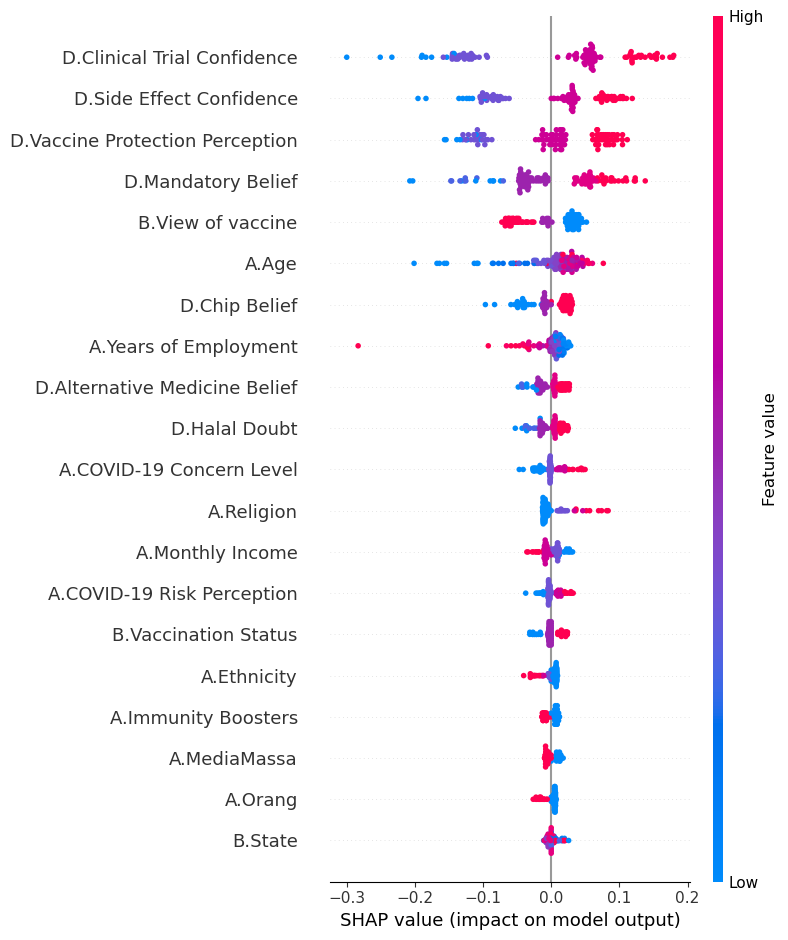

In [18]:
# Extract SHAP values for class 1
shap_values_class_1 = shap_values[:, :, 1]  # Select the 2nd output (class 1)

# Debug dimensions
print(f"SHAP Values for Class 1 Shape: {shap_values_class_1.shape}")  # Should match (111, 69)

# Generate summary plot
shap.summary_plot(shap_values_class_1, X_test, feature_names=X_test.columns)

# Local

In [21]:
shap_values = explainer.shap_values(X_test.iloc[0, :])  # Get SHAP values for the first sample
shap.force_plot(explainer.expected_value[1], shap_values[:,1], X_test.iloc[0, :])  # Force plot for class 1


In [23]:
shap_values = explainer.shap_values(X_test) 

  0%|          | 0/111 [00:00<?, ?it/s]

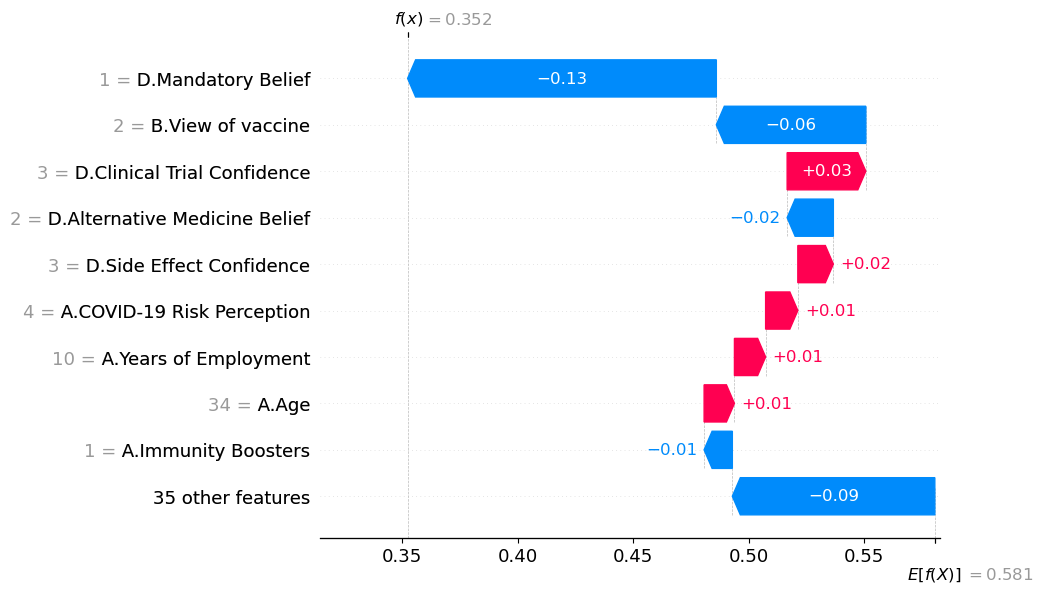

In [24]:
# Choose the index of the instance you want to explain (e.g., instance 0)
instance_index = 0

# Extract SHAP values for the selected instance and class (e.g., class 1)
shap_values_instance_class_1 = shap_values[instance_index, :, 1]

# Get the feature values for that instance
feature_values = X_test.iloc[instance_index]

# Plot the waterfall chart for the chosen instance and class
shap.waterfall_plot(
    shap.Explanation(values=shap_values_instance_class_1, 
                     base_values=explainer.expected_value[1],  # Base value for class 1
                     data=feature_values, 
                     feature_names=X_test.columns)
)